# Logistic Regression (Perceptron-style view)

This notebook builds intuition in two stages:

1. **Perceptron**: learns a *linear decision boundary* using a hard step function.
2. **Logistic Regression**: uses the *same linear score* $z = w^T x$ but converts it to a probability with the sigmoid function and learns $w$ by minimizing **log-loss**.

A useful mental model is:

- Perceptron update: $w \leftarrow w + \eta\,(y-\hat y)\,x$ with $\hat y = \mathbb{1}[w^T x > 0]$
- Logistic regression (SGD) update: $w \leftarrow w - \eta\,(\sigma(w^T x)-y)\,x$

Both end up with a line (in 2D) separating the classes; logistic regression additionally gives **probabilities**.

## Why use Logistic Regression instead of a Perceptron?

Even though both can learn a linear boundary, logistic regression is usually preferred in practice because:

- **Probabilities (confidence)**: perceptron outputs only $0/1$, while logistic regression outputs $p(y=1\mid x)\in(0,1)$, which is useful for ranking, threshold tuning, and decision-making under uncertainty.
- **Optimizes a smooth objective**: logistic regression minimizes **log-loss**, which is differentiable (and convex for linear models). That makes training more stable and compatible with gradient-based optimization.
- **Works better with non-separable/noisy data**: perceptron can fail to converge when classes overlap; logistic regression still learns by trading off errors via its loss.
- **Regularization is standard**: logistic regression naturally supports L2/L1 regularization to reduce overfitting and handle correlated features.
- **Same boundary idea, better learning signal**: perceptron updates are based on a hard mistake; logistic regression updates scale with $(p-y)$, so it learns “how wrong” it is, not just whether it is wrong.

In [1]:
from sklearn.datasets import make_classification
import numpy as np;
X,y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0,n_classes=2,n_clusters_per_class=1,hypercube=False,class_sep=10, random_state=41)

In [2]:
X

array([[ 0.19924745, -0.11697552],
       [-0.24882029, -0.73115232],
       [-0.3544904 , -0.7081059 ],
       [-1.59086506, -2.01199214],
       [-0.20083951,  1.63493163],
       [-0.83241122,  0.15599044],
       [-1.79207014,  1.07782053],
       [ 0.0856607 ,  0.80626713],
       [-0.55865299,  0.74859527],
       [-1.95974262,  0.75152794],
       [-1.77828947, -0.90114581],
       [-1.77985853, -0.1815243 ],
       [-0.02194151, -2.98092432],
       [ 0.80563431,  1.20500136],
       [-1.82701214,  0.78302407],
       [ 0.38730728,  0.42968688],
       [-0.14108668, -0.73229726],
       [-1.87955941, -0.83930476],
       [-0.18232911,  0.83727062],
       [-1.77059533, -0.10255323],
       [-2.27658028,  0.65867001],
       [-2.06519502,  0.92649819],
       [-1.31690551,  0.10216193],
       [ 1.61043259,  0.46886454],
       [-1.21650394,  0.45432938],
       [ 0.6139723 ,  1.8613386 ],
       [-1.78760957, -0.79255991],
       [-1.04149161, -1.0004391 ],
       [-2.40067584,

In [3]:
y

array([1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

## 1) Dataset (2 features, binary target)

We generate a 2D classification dataset:

- $X \in \mathbb{R}^{n \times 2}$ contains two features per sample: $x = [x_1, x_2]$
- $y \in \{0,1\}^n$ is the class label

Because the data are linearly separable (high `class_sep`), a **linear classifier** like perceptron or logistic regression can learn a good boundary.

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

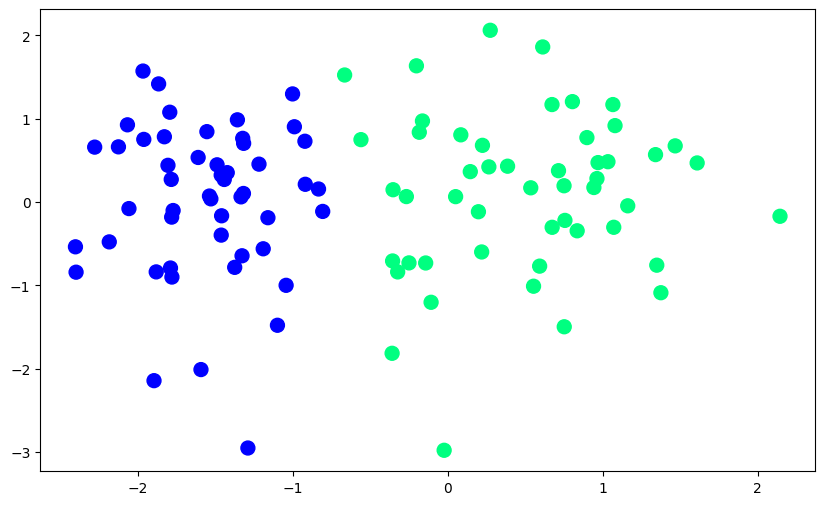

In [5]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)


## 2) Visualize the classes

Each point is a sample $(x_1, x_2)$. Colors indicate class $y$.

Goal: learn a line that separates the two colors as well as possible.

## 3) Perceptron baseline (hard-threshold classifier)

The perceptron defines a **linear score**

$$z = w^T x + w_0$$

and predicts using a hard step:

$$\hat y = \mathbb{1}[z > 0]$$

### Bias trick used in the code
We append a constant 1 to every sample:

$$\tilde x = [1, x_1, x_2]$$

so the bias becomes just another weight, and we can write $z = \tilde w^T \tilde x$.

### Perceptron weight update
For a sampled point $(x, y)$, the classic online update is:

$$\tilde w \leftarrow \tilde w + \eta\,(y-\hat y)\,\tilde x$$

This is exactly what the function below implements.

In [6]:
def perceptron(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]

In [7]:
def step(z):
    return 1 if z>0 else 0

In [8]:
intercept_,  coef_ = perceptron(X,y)

In [9]:
print(intercept_, coef_)

1.0 [1.31865339 0.06271614]


In [10]:
m = - (coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

print(f'm: {m}, b: {b}')

m: -21.025741254882156, b: -15.94485813335863


## 4) From weights to the decision boundary line (slope/intercept)

After training, we have three weights because we inserted the bias term:

$$\tilde w = [w_0, w_1, w_2]$$

The **decision boundary** is where the model is indifferent between classes, i.e. where the score is zero:

$$w_0 + w_1 x_1 + w_2 x_2 = 0$$

Solve for $x_2$ to get a straight line:

$$x_2 = -\frac{w_1}{w_2}x_1 - \frac{w_0}{w_2}$$

So the notebook computes:

- slope $m = -\frac{w_1}{w_2}$
- intercept $b = -\frac{w_0}{w_2}$

and then plots $x_2 = m x_1 + b$.

In [11]:
X_input = np.linspace(-3,3,100)
y_input = m*X_input + b

(-3.0, 2.0)

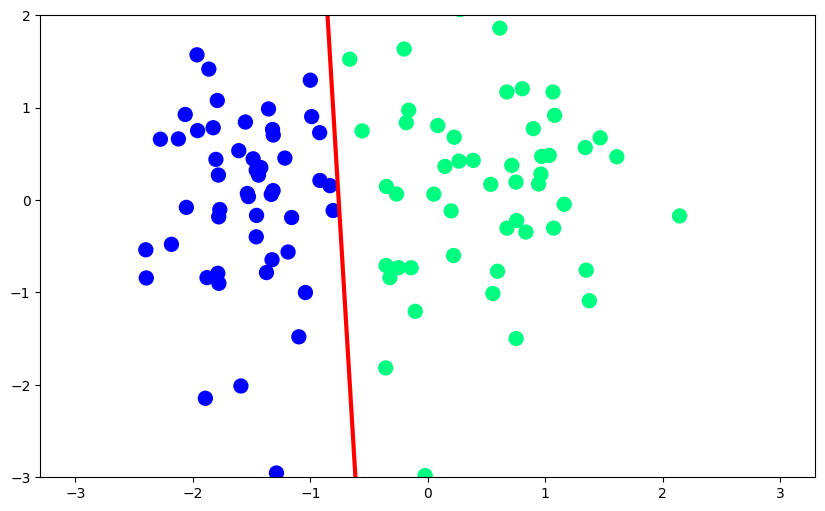

In [12]:
plt.figure(figsize=(10,6))
plt.plot(X_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [13]:
def perceptron(X,y):
    
    m = []
    b = []
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(200):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))
        
    return m,b

In [14]:
m,b = perceptron(X,y)

## 5) Animating perceptron learning

To animate the learning process, we re-run the perceptron update but **store the boundary parameters after each update**:

- After each weight update, compute the current line slope/intercept:
  $$m_i = -\frac{w_{1,i}}{w_{2,i}}, \quad b_i = -\frac{w_{0,i}}{w_{2,i}}$$
- Keep sequences $\{m_i\}$ and $\{b_i\}$, then draw the line $x_2 = m_i x_1 + b_i$ per frame.

That’s why the next perceptron function returns arrays `m` and `b` instead of a single final weight vector.

In [15]:
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
from IPython.display import Image, display

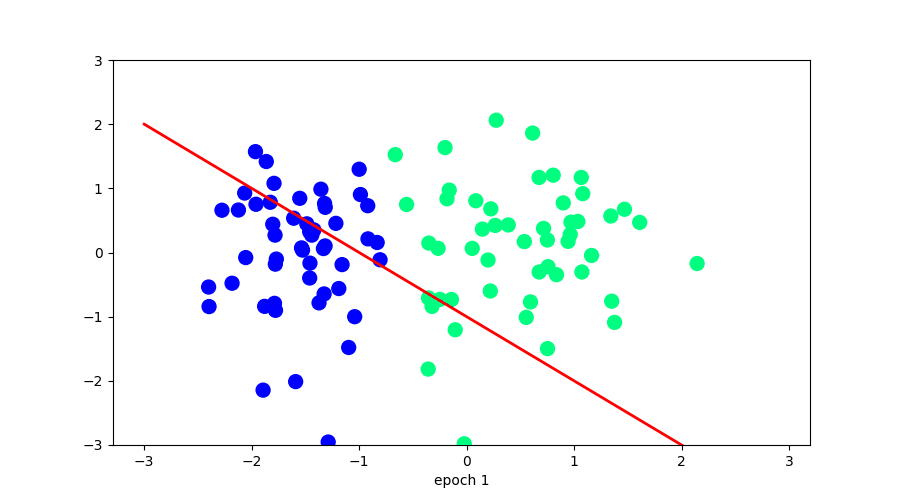

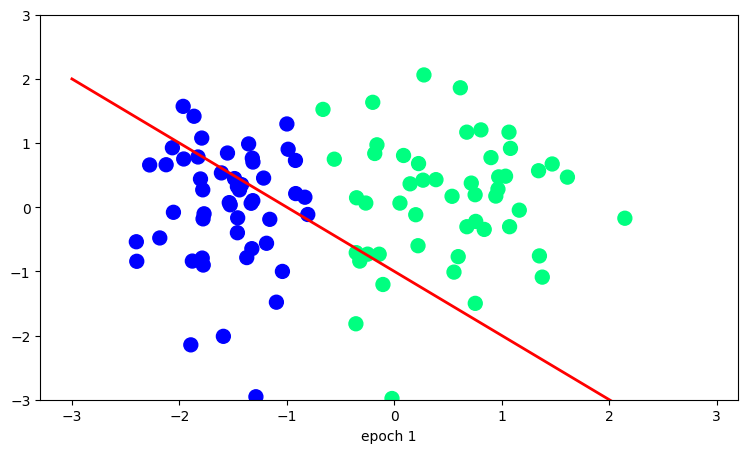

In [16]:
fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m[0] +b[0]
ax.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
line, = ax.plot(x_i, x_i*m[0] +b[0] , 'r-', linewidth=2)
plt.ylim(-3,3)
def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)
    # return line, ax

anim = FuncAnimation(fig, update, repeat=True, frames=200, interval=100)
anim.save("Preceptron Logistic Regression.gif", writer=animation.PillowWriter(fps=10))
display(Image("Preceptron Logistic Regression.gif"))

## 6) Logistic Regression: perceptron-style training, but probabilistic

Perceptron uses a hard decision rule (step function). Logistic regression keeps the same linear score $z = \tilde w^T \tilde x$, but maps it to a probability:

$$p(y=1\mid x) = \sigma(z) = \frac{1}{1 + e^{-z}}$$

Prediction is still based on the sign of $z$ (equivalently $p\ge 0.5$):

$$\hat y = 1 \iff p \ge 0.5 \iff z \ge 0$$

So **the boundary is the same type of line**, but learning is different.

### Log-loss (negative log-likelihood)
For one sample $(x, y)$ with $y\in\{0,1\}$, define:

- $z = \tilde w^T \tilde x$
- $p = \sigma(z)$

The logistic regression loss is:

$$\ell(\tilde w) = -\Big[y\log(p) + (1-y)\log(1-p)\Big]$$

### Complete derivation of the gradient (weights/features)
We differentiate step-by-step.

1) Derivative of the sigmoid:

$$\sigma(z)=\frac{1}{1+e^{-z}} \quad\Rightarrow\quad \frac{d\sigma}{dz} = \sigma(z)(1-\sigma(z)) = p(1-p)$$

2) Differentiate loss wrt $p$:

$$\ell = -\big[y\log p + (1-y)\log(1-p)\big]$$

$$\frac{\partial \ell}{\partial p} = -\Big(\frac{y}{p} - \frac{1-y}{1-p}\Big)$$

3) Chain rule to get $\partial\ell/\partial z$:

$$\frac{\partial \ell}{\partial z} = \frac{\partial \ell}{\partial p}\cdot\frac{dp}{dz}$$

Plugging in $dp/dz=p(1-p)$ and simplifying gives the famous result:

$$\frac{\partial \ell}{\partial z} = p - y$$

4) Now use $z = \tilde w^T \tilde x$ so $\partial z/\partial \tilde w = \tilde x$:

$$\nabla_{\tilde w}\,\ell(\tilde w) = (p-y)\,\tilde x$$

This explicitly shows how **each feature** contributes to the gradient: the gradient is proportional to that feature value.

### SGD / perceptron-style update rule
Using gradient descent on one sample:

$$\tilde w \leftarrow \tilde w - \eta\,(p-y)\,\tilde x$$

Compare with perceptron:

- perceptron uses $\hat y\in\{0,1\}$ from a step function
- logistic regression uses $p\in(0,1)$ from a sigmoid

So logistic regression is like a “smooth perceptron” that updates by **how wrong the probability is**, not just whether the prediction was wrong.

### Vectorized (batch) gradient (all samples)
Let $\tilde X\in\mathbb{R}^{n\times 3}$ be the matrix with the bias column inserted, $p=\sigma(\tilde X\tilde w)$ elementwise. Then:

$$\nabla_{\tilde w} L(\tilde w) = \tilde X^T(p-y)$$

In [17]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## 7) Using `sklearn` LogisticRegression (reference implementation)

`sklearn.linear_model.LogisticRegression` fits the same model:

$$p(y=1\mid x) = \sigma(w_0 + w_1 x_1 + w_2 x_2)$$

After fitting:

- `lor.coef_` contains $[w_1, w_2]$
- `lor.intercept_` contains $w_0$

The decision boundary is again $w_0 + w_1 x_1 + w_2 x_2 = 0$, so:

$$x_2 = -\frac{w_1}{w_2}x_1 - \frac{w_0}{w_2}$$

Note: by default, sklearn applies **regularization** (typically L2) and uses a numerical optimizer, so its line can differ slightly from the perceptron-trained boundary.

In [18]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])

In [19]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*X_input + b

(-3.0, 2.0)

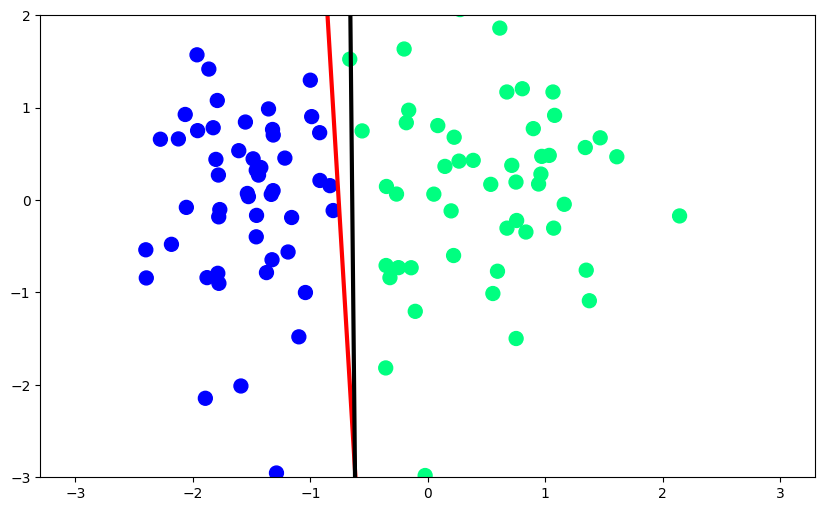

In [20]:
plt.figure(figsize=(10,6))
plt.plot(X_input,y_input,color='red',linewidth=3) # this is the line from perceptron
plt.plot(x_input1,y_input1,color='black',linewidth=3) # this is the line from logistic regression
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

## Takeaways

- **Perceptron** learns a boundary using a hard step; updates happen only based on discrete mistakes.
- **Logistic regression** learns the same type of boundary, but via a smooth probability model and log-loss; updates scale with $(p-y)$.
- The derived gradient $\nabla\ell = (\sigma(w^T x) - y)x$ is the key result: it shows exactly how the weights (including bias via the inserted 1) are updated from the features.